## Assignment 6

Name: Shreni Bandgar

Roll no:EN23107003

Batch: A


Training Naive Bayes...
Naive Bayes Results:
Accuracy : 0.9785
Precision: 1.0000
Recall   : 0.8389
F1-Score : 0.9124

Training Logistic Regression...
Logistic Regression Results:
Accuracy : 0.9695
Precision: 1.0000
Recall   : 0.7718
F1-Score : 0.8712

Training Linear SVM...
Linear SVM Results:
Accuracy : 0.9901
Precision: 0.9929
Recall   : 0.9329
F1-Score : 0.9619

Training Random Forest...
Random Forest Results:
Accuracy : 0.9812
Precision: 1.0000
Recall   : 0.8591
F1-Score : 0.9242

Training KNN...
KNN Results:
Accuracy : 0.9130
Precision: 1.0000
Recall   : 0.3490
F1-Score : 0.5174

 FINAL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-Score
2           Linear SVM  0.990135   0.992857  0.932886  0.961938
3        Random Forest  0.981166   1.000000  0.859060  0.924188
0          Naive Bayes  0.978475   1.000000  0.838926  0.912409
1  Logistic Regression  0.969507   1.000000  0.771812  0.871212
4                  KNN  0.913004   1.000000  0.348993  0.517413


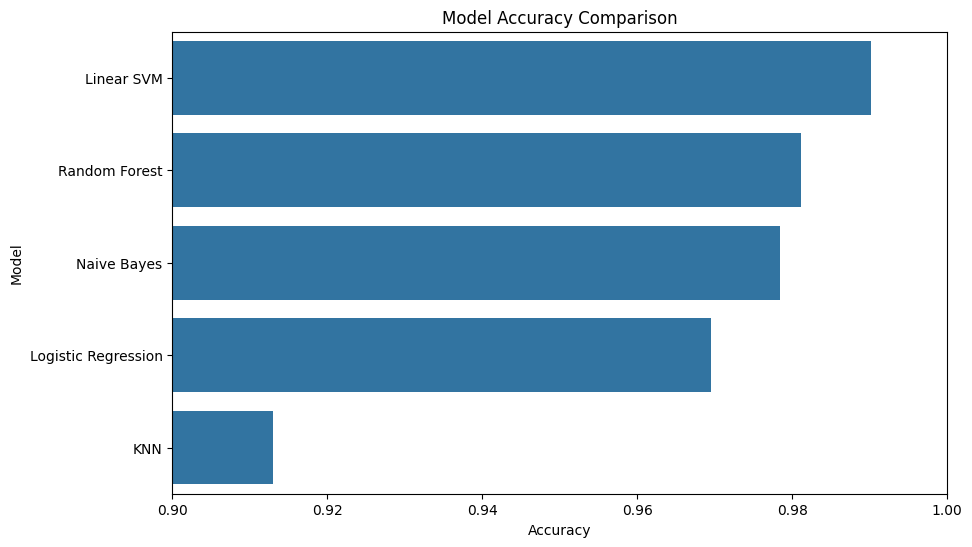

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier




data = pd.read_csv("SMSSpamCollection", sep="\t", header=None, names=["label", "message"])

data['label'] = data['label'].map({'ham': 0, 'spam': 1})

X = data['message']
y = data['label']



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []



for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, accuracy, precision, recall, f1])
    
    print(f"{name} Results:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")



results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])

print("\n FINAL COMPARISON")
print(results_df.sort_values(by="Accuracy", ascending=False))


plt.figure(figsize=(10,6))
sns.barplot(x="Accuracy", y="Model", data=results_df.sort_values(by="Accuracy", ascending=False))
plt.title("Model Accuracy Comparison")
plt.xlim(0.9, 1.0)
plt.show()

In [9]:



print("\nSAMPLE TEST PREDICTIONS")

test_results = pd.DataFrame({
    "Message": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

test_results["Actual"] = test_results["Actual"].map({0: "HAM", 1: "SPAM"})
test_results["Predicted"] = test_results["Predicted"].map({0: "HAM", 1: "SPAM"})


print(test_results.head(10))



===== SAMPLE TEST PREDICTIONS =====
                                             Message Actual Predicted
0  Squeeeeeze!! This is christmas hug.. If u lik ...    HAM       HAM
1  And also I've sorta blown him off a couple tim...    HAM       HAM
2  Mmm thats better now i got a roast down me! i...    HAM       HAM
3      Mm have some kanji dont eat anything heavy ok    HAM       HAM
4  So there's a ring that comes with the guys cos...    HAM       HAM
5  Sary just need Tim in the bollox &it hurt him ...    HAM       HAM
6  Love isn't a decision, it's a feeling. If we c...    HAM       HAM
7  My supervisor find 4 me one lor i thk his stud...    HAM       HAM
8                 Dear good morning now only i am up    HAM       HAM
9                         I'm in chennai velachery:)    HAM       HAM
